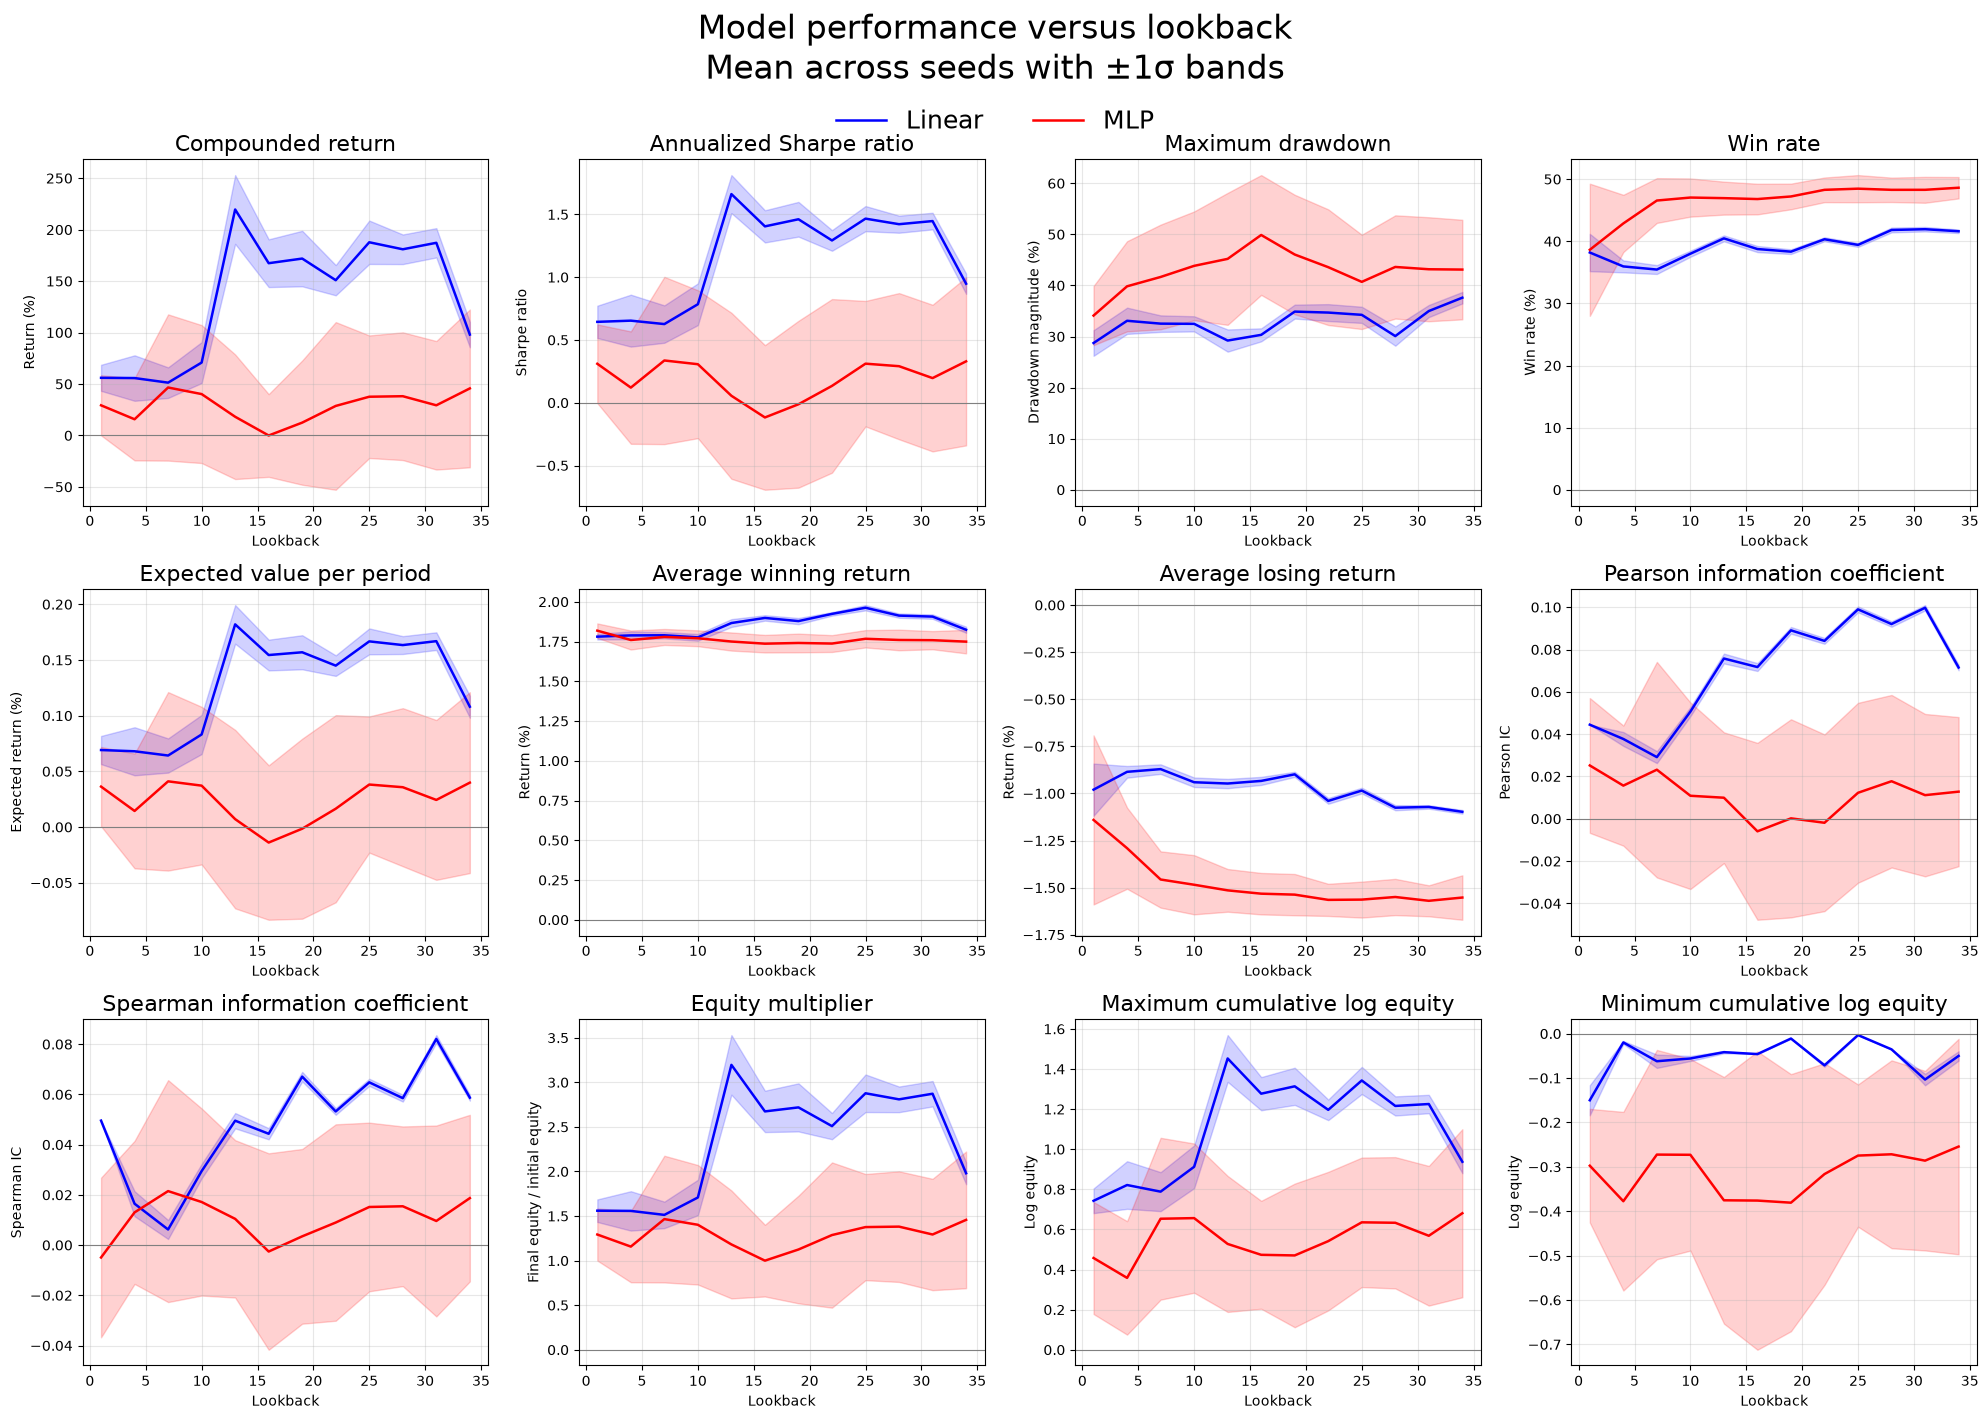

In [ ]:
# This figure plot code is written by ai.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scienceplots

# ==================================================
# Load results
# ==================================================

results_path = Path(
    "seed_metrics.csv"
)

metrics = pd.read_csv(results_path)

# ==================================================
# Create interpretable derived quantities
# ==================================================

metrics["compounded_return_pct"] = (
    metrics["compounded_return"] * 100
)

metrics["max_drawdown_pct"] = (
    -metrics["drawdown_percentage"] * 100
)

metrics["win_rate_pct"] = (
    metrics["win_rate"] * 100
)

metrics["average_win_pct"] = (
    np.expm1(metrics["average_win"])
    * 100
)

metrics["average_loss_pct"] = (
    np.expm1(metrics["average_loss"])
    * 100
)

metrics["expected_value_pct"] = (
    np.expm1(
        metrics["expected_value_per_trade"]
    )
    * 100
)

metrics["return_std_pct"] = (
    metrics["return_std"] * 100
)

# ==================================================
# Metrics to plot
# ==================================================

plot_metrics = {
    "compounded_return_pct": (
        "Compounded return",
        "Return (%)",
    ),

    "annualized_sharpe_crypto": (
        "Annualized Sharpe ratio",
        "Sharpe ratio",
    ),

    "max_drawdown_pct": (
        "Maximum drawdown",
        "Drawdown magnitude (%)",
    ),

    "win_rate_pct": (
        "Win rate",
        "Win rate (%)",
    ),

    "expected_value_pct": (
        "Expected value per period",
        "Expected return (%)",
    ),

    "average_win_pct": (
        "Average winning return",
        "Return (%)",
    ),

    "average_loss_pct": (
        "Average losing return",
        "Return (%)",
    ),

    "pearson_ic": (
        "Pearson information coefficient",
        "Pearson IC",
    ),

    "spearman_ic": (
        "Spearman information coefficient",
        "Spearman IC",
    ),

    "equity_multiplier": (
        "Equity multiplier",
        "Final equity / initial equity",
    ),

    "equity_peak": (
        "Maximum cumulative log equity",
        "Log equity",
    ),

    "equity_trough": (
        "Minimum cumulative log equity",
        "Log equity",
    ),
}

# ==================================================
# Average across seeds
# ==================================================

statistics = (
    metrics
    .groupby(
        ["model", "lag"]
    )[list(plot_metrics)]
    .agg(["mean", "std"])
    .sort_index()
)

# ==================================================
# Plot
# ==================================================

models = sorted(
    metrics["model"].unique()
)

colors = {
    "MLP": "red",
    "Linear": "blue",
}

fig, axes = plt.subplots(
    3,
    4,
    figsize=(20, 14),
)

axes = axes.flatten()

for ax, (
    metric,
    (title, ylabel),
) in zip(
    axes,
    plot_metrics.items(),
):
    for model in models:
        model_statistics = (
            statistics.xs(
                model,
                level="model",
            )
        )

        lookbacks = (
            model_statistics.index
            .to_numpy()
        )

        mean = (
            model_statistics[
                (metric, "mean")
            ]
            .to_numpy()
        )

        std = (
            model_statistics[
                (metric, "std")
            ]
            .fillna(0.0)
            .to_numpy()
        )

        color = colors.get(
            model,
            None,
        )

        ax.plot(
            lookbacks,
            mean,
            color=color,
            linewidth=1.8,
            label=model,
        )

        ax.fill_between(
            lookbacks,
            mean - std,
            mean + std,
            color=color,
            alpha=0.18,
        )

    ax.axhline(
        0,
        color="grey",
        linewidth=0.8,
    )

    ax.set_title(title,size=16)
    ax.set_xlabel("Lookback")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

# Hide unused subplots, if any.
for ax in axes[
    len(plot_metrics):
]:
    ax.set_visible(False)

# Shared legend and figure title.
handles, labels = (
    axes[0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(models),
    frameon=False,
    fontsize=18,
    bbox_to_anchor=(0.5, 0.955)
)

fig.suptitle(
    "Model performance versus lookback\n"
    "Mean across seeds with ±1σ bands (BTH)",
    fontsize=24,
    
    y=1.01,
)

fig.tight_layout()
plt.savefig("benchmark_BTH.png",dpi = 500)
plt.show()